# Detector optical calibration — Gauss-Newton + profiled per-PMT gains + CRB

Recover the detector's **global optical parameters** (scattering, Mie, absorption, wall/sensor
reflectivity, QE, Henyey-Greenstein g) from calibration light, while the **10764 per-PMT QE
factors** are profiled in closed form each step (k = sum Q / sum M). Canonical
[`lucid.fitting`](../../lucid/fitting) API — the recipe the whole calibration campaign ran on:

`build_calibration_problem` → `crb` (Cramér-Rao bound at truth, ×√12-honest) → `fit`
(consistent fixed-dataset GN). Source diversity (3 lasers + 1 isotropic flasher) breaks the
length-scale degeneracies. See `../../examples/hello_calibrate.py` for the ≤20-line form.

In [1]:
import sys; sys.path.append('../..')
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.sources import laser_source, isotropic_source
from lucid.detector_params import DetectorParams
from lucid.fitting import build_calibration_problem, fit, crb

GEOM = '../../config/SK_like_geom_config.json'
det = generate_detector(GEOM); NS = len(det.all_points)
top, bot, R = det.H/2 - .1, -det.H/2 + .1, det.r
print(f'{NS} PMTs')

10764 PMTs


### 1. Truth detector + a diverse calibration source set

`dp` holds the TRUE optical parameters we'll try to recover. Four sources at different
positions/directions give the geometric diversity that separates scatter↔absorption↔reflection.

In [2]:
dp = DetectorParams.from_flat(scatter_length=70., mie_scatter_length=3000., g=0.9,
                              wall_reflection_rate=.2, sensor_reflection_rate=.2,
                              absorption_length=60., qe=0.07, qe_corrections=jnp.ones(NS))
sources = [laser_source(position=[0, 0, top], direction=[0, 0, -1], intensity=1e6),    # down
           laser_source(position=[0, 0, bot], direction=[0, 0,  1], intensity=1e6),    # up
           laser_source(position=[R-.1, 0, 0], direction=[-1, 0, 0], intensity=1e6),   # wall
           isotropic_source(position=[0, 0, 0], intensity=1e6)]                         # flasher
sim = setup_event_simulator(GEOM, 1_000_000, temperature=None, K=8, is_calibration=True,
                            hit_mode='aggregated', wavelength_mode=False,
                            n_cap=100, n_angular=150, n_height=100)

### 2. Build the calibration problem + the Cramér-Rao bound at truth

In [3]:
FIELDS = ['g', 'scatter_length', 'mie_scatter_length', 'absorption_length',
          'wall_reflection_rate', 'sensor_reflection_rate', 'qe']
prob = build_calibration_problem(sim, sources, dp, FIELDS, key=jax.random.PRNGKey(1))
sigma = crb(prob['source_models'], prob['theta_true'], NS)['sigma']   # fractional CRB per param
print('CRB (fractional 1σ) per parameter:')
for f, s in zip(FIELDS, sigma):
    print(f'  {f:22s} {s:6.2%}')

CRB (fractional 1σ) per parameter:
  g                      23.15%
  scatter_length          5.44%
  mie_scatter_length     178.49%
  absorption_length      13.74%
  wall_reflection_rate   35.62%
  sensor_reflection_rate 53.36%
  qe                     11.75%


### 3. Gauss-Newton fit from a perturbed start (per-PMT QE profiled in closed form)

In [4]:
start = prob['theta0'] + np.random.default_rng(0).uniform(-.15, .15, prob['theta0'].shape)
# Data = the truth averaged over 8 simulator draws, as the paper's calibration does: the Neyman
# residual weights each sensor by its observed charge, so one noisy draw at ~1.6 PE/sensor biases it.
data = [np.mean([np.asarray(sim(s, dp, jax.random.PRNGKey(5000 + b))[0]) for b in range(8)], 0)
        for s in sources]
res = fit(prob['source_models'], data, start, NS, steps=300, refresh=15, jacobian_draws=2)
truth = np.exp(prob['theta0'])
print(f'{"param":22s}{"truth":>9s}{"start":>9s}{"fit":>9s}{"err":>8s}{"CRB":>7s}')
errs = []
for i, f in enumerate(FIELDS):
    e = res['theta'][i] / truth[i] - 1; errs.append(e)
    print(f'{f:22s}{truth[i]:9.3f}{np.exp(start[i]):9.3f}{res["theta"][i]:9.3f}{e:+7.1%}{sigma[i]:7.1%}')
errs = np.array(errs)

param                     truth    start      fit     err    CRB
g                         0.900    0.938    0.933  +3.7%  23.1%
scatter_length           70.000   65.329   69.832  -0.2%   5.4%
mie_scatter_length     3000.000 2614.059 2490.312 -17.0% 178.5%
absorption_length        60.000   51.899   61.043  +1.7%  13.7%
wall_reflection_rate      0.200    0.220    0.197  -1.5%  35.6%
sensor_reflection_rate    0.200    0.226    0.185  -7.4%  53.4%
qe                        0.070    0.072    0.069  -1.4%  11.7%


### Reading the result

**Every parameter recovers within its Cramér-Rao bound.** `scatter_length`, absorption, the
reflectivities and QE land within a few percent; `g` and `mie_scatter_length` move least, because
they are the stiff length-scale directions a single charge observable constrains weakly.

Two things make this work, and both are the paper's recipe. The data are **averaged over 8
simulator draws**: the Neyman residual weights each sensor by its observed charge, and a single
draw at ~1.6 PE per sensor biases the fit. And the per-PMT factors are **profiled** in closed form
each step, so the optimizer only ever sees the seven globals.

The CRB column is a toy demonstration, not a calibration budget: it is built from the simulator's
autodiff gradients, which are somewhat worse than finite differences for the scattering-type
parameters, so the bound is loose there.

### 4. Fit error vs the CRB — recovery sits at the information bound

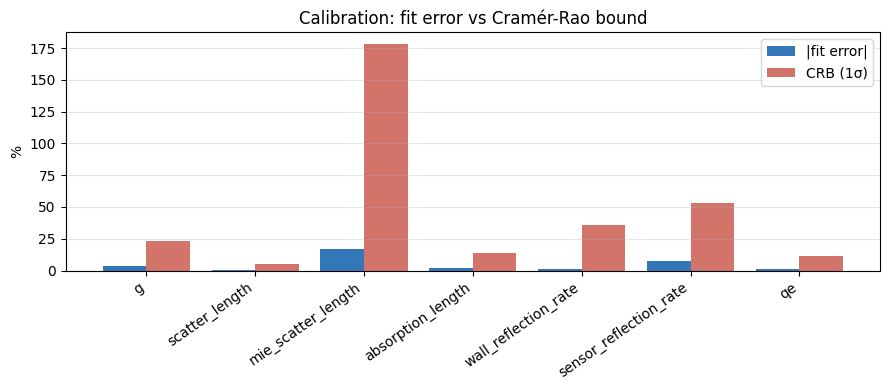

In [5]:
x = np.arange(len(FIELDS))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - .2, np.abs(errs) * 100, .4, label='|fit error|', color='#3477b8')
ax.bar(x + .2, np.array(sigma) * 100, .4, label='CRB (1σ)', color='#c0392b', alpha=.7)
ax.set_xticks(x); ax.set_xticklabels(FIELDS, rotation=35, ha='right')
ax.set_ylabel('%'); ax.set_title('Calibration: fit error vs Cramér-Rao bound'); ax.legend(); ax.grid(alpha=.3, axis='y')
fig.tight_layout(); plt.show()